In [ ]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")



def savefig(fig, plot_save, name):
    fig.savefig(f'{plot_save}/{name}.png', transparent=True, bbox_inches='tight', dpi=600)



# Load svaed checkpoint using Experiment config

In [10]:
config_dir = "logs/tompos_leavout_t5n7/pde_params"
config_files = [f"{config_dir}/V{i}_config.json" for i in range(0,4)]

config_files

['logs/tompos_leavout_t5n7/pde_params/V0_config.json',
 'logs/tompos_leavout_t5n7/pde_params/V1_config.json',
 'logs/tompos_leavout_t5n7/pde_params/V2_config.json',
 'logs/tompos_leavout_t5n7/pde_params/V3_config.json']

In [12]:
DS_configs = []
ckpts = []
for config_file in config_files:
    configV = PINN.ExperimentConfig(config=config_file)
    DS_configs.append(configV.dataset_config)
    ckpts.append(configV.find_lastest_ckpt())

In [65]:
for config_file in config_files:
    configV = PINN.ExperimentConfig(config=config_file)
    print(configV.model_config)

{'model_class': 'pde_params', 'channels': None, 'activation_fn': None, 'ode_tol': 0.0001, 'D_penalty': 0.1, 'deltax_weight': 0.01, 'weight_intensity': 3.0, 'time_scale_factor': 5, 'time_sensitive': False, 'v_channels': [10, 64, 64, 10], 'g_channels': [10, 64, 64, 1], 'D_channels': [10, 64, 64, 10]}
{'model_class': 'pde_params', 'channels': None, 'activation_fn': None, 'ode_tol': 0.0001, 'D_penalty': 0.1, 'deltax_weight': 0.01, 'weight_intensity': 3.0, 'time_scale_factor': 5, 'time_sensitive': False, 'v_channels': [10, 64, 64, 10], 'g_channels': [10, 64, 64, 1], 'D_channels': [10, 64, 64, 10]}
{'model_class': 'pde_params', 'channels': None, 'activation_fn': None, 'ode_tol': 0.0001, 'D_penalty': 0.1, 'deltax_weight': 0.01, 'weight_intensity': 1.0, 'time_scale_factor': 5, 'time_sensitive': False, 'v_channels': [10, 64, 64, 10], 'g_channels': [10, 64, 64, 1], 'D_channels': [10, 64, 64, 10]}
{'model_class': 'pde_params', 'channels': None, 'activation_fn': None, 'ode_tol': 0.0001, 'D_penalty

In [13]:
model0 = PINN.models.pde_params.load_from_checkpoint(ckpts[0])
model1 = PINN.models.pde_params.load_from_checkpoint(ckpts[1])
model2 = PINN.models.pde_params.load_from_checkpoint(ckpts[2])
model3 = PINN.models.pde_params.load_from_checkpoint(ckpts[3])

In [66]:
# the dataset config is the same among all versions
for config_file in config_files:
    configV = PINN.ExperimentConfig(config=config_file)
    print(configV.dataset_config)

{'cellstate_key': 'DM_scaled', 'n_grid': 300, 'n_dimension': 10, 'kde_kws': {'bw_method': None}, 'timepoint_idx': [0, 1, 2, 3, 4, 6, 8], 'deltax_key': 'Delta_DM', 'norm_time': False}
{'cellstate_key': 'DM_scaled', 'n_grid': 300, 'n_dimension': 10, 'kde_kws': {'bw_method': None}, 'timepoint_idx': [0, 1, 2, 3, 4, 6, 8], 'deltax_key': 'Delta_DM', 'norm_time': False}
{'cellstate_key': 'DM_scaled', 'n_grid': 300, 'n_dimension': 10, 'kde_kws': {'bw_method': None}, 'timepoint_idx': [0, 1, 2, 3, 4, 6, 8], 'deltax_key': 'Delta_DM', 'norm_time': False}
{'cellstate_key': 'DM_scaled', 'n_grid': 300, 'n_dimension': 10, 'kde_kws': {'bw_method': None}, 'timepoint_idx': [0, 1, 2, 3, 4, 6, 8], 'deltax_key': 'Delta_DM', 'norm_time': False}


In [7]:
# so we can load 1 DS
adata = sc.read_h5ad("data/tom_pos.h5ad")

In [ ]:
# set to full timepoints
DS_configs[0]['timepoint_idx'] = None
DS_full = PINN.reader.TwoTimpepoint_AnnDS(AnnData=adata, **DS_configs[0])
DM_range = DS_full.cellstate.max(axis=0, keepdims=True) - DS_full.cellstate.min(axis=0, keepdims=True)

if DS_configs[0]['norm_time'] != 'min_minus':
    day0 = adata.uns['pop']['t'][0]
else:
    day0 = 1

Computing density :
`density_funs` not specified, use gaussian kde


In [70]:
def get_norm(v):

    v_norm = v / DM_range[None,:, :]
    v_norm = np.sqrt(np.sum(v_norm**2, axis=2))

    return v_norm

params = {}

for i, modelV in enumerate([model0, model1, model2, model3]):

    g,v,D = modelV.predict_param(train_DS=DS_full)
    g /= day0
    v /= day0
    D /= day0

    v_norm = get_norm(v)
    D_norm = get_norm(D)

    params["V"+str(i)] = g, v_norm, D_norm

In [71]:
params.keys()

dict_keys(['V0', 'V1', 'V2', 'V3'])

In [77]:
ad_plot = adata.copy()

prediction of shape (9, 49390)
prediction of shape (9, 49390)
prediction of shape (9, 49390)


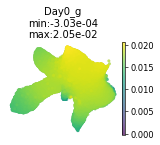

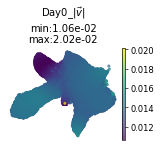

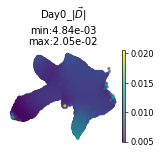

In [76]:
v = 0

plt.ion()
figg, axs = PINN.pl.params_in_umap(adata, params[f'V{v}'][0], param='g', timepoints=[0], cell_of_t=False, subplot_kws={'dpi':60});
figv, axs = PINN.pl.params_in_umap(adata, params[f'V{v}'][1], param=r'$|\vec{v}|$', timepoints=[0], cell_of_t=False, subplot_kws={'dpi':60});
figD, axs = PINN.pl.params_in_umap(adata, params[f'V{v}'][2], param=r'$|\vec{D}|$', timepoints=[0], cell_of_t=False, subplot_kws={'dpi':60});

In [ ]:
plot_save = '/ssd/users/Wergillius/Project/PINN_dynamics/results/tompos_time_inv/pde_params'

def savefig(fig, name):
    fig.savefig(f'{plot_save}/{name}.png', transparent=True, bbox_inches='tight', dpi=600)
    fig.savefig(f'{plot_save}/{name}.pdf', transparent=True, bbox_inches='tight', dpi=600)
    fig.savefig(f'{plot_save}/{name}.svg', transparent=True, bbox_inches='tight', dpi=600)

plt.ioff()

for v in range(4):

    g = params[f'V{v}'][0][0]
    gclip = np.quantile(g, [0.999])
    ad_plot.obs['growth']  = np.where(g<=gclip, g, gclip)
    figg = plt.figure(figsize=(5,5), frameon=False, dpi=600)
    sc.pl.umap(ad_plot, color=['growth'], title='static model growth rate', ax=figg.gca(), frameon=False, show=False, size=30)
    savefig(figg, f"V{v}_g")
    figg.show(False)

    vnorm = params[f'V{v}'][1][0]
    # vclip = np.quantile(vnorm, [0.999])
    # ad_plot.obs['drift'] = np.where(vnorm<=vclip, vnorm, vclip)
    # figv = plt.figure(figsize=(5,5), frameon=False, dpi=600)
    # sc.pl.umap(ad_plot, color=['drift'],  title=r'static model diff rate ($|\vec{v}|$)', ax=figv.gca(), frameon=False, show=False, size=30)
    # savefig(figv, f"V{v}_v")
    # figv.show(False)

    # D = params[f'V{v}'][2][0]
    # Dclip = np.quantile(D, [0.999])
    # ad_plot.obs['drift'] = np.where(D<=Dclip, D, Dclip)
    # figD = plt.figure(figsize=(5,5), frameon=False, dpi=600)
    # sc.pl.umap(ad_plot, color=['drift'],  title=r'static model diffusion rate ($|\vec{D}|$)', ax=figD.gca(), frameon=False, show=False, size=30)
    # savefig(figD, f"V{v}_D")
    # figD.show(False)

In [120]:
v = 1
D = params[f'V{v}'][2][0]
Dclip = np.quantile(D, [0.999])
ad_plot.obs['drift'] = np.where(D<=Dclip, D, Dclip)
figD = plt.figure(figsize=(5,5), frameon=False, dpi=600)
sc.pl.umap(ad_plot, color=['drift'],  title=r'static model diff rate ($|\vec{D}|$)', ax=figD.gca(), frameon=False, show=False, size=30)
savefig(figD, f"V{v}_D")
figD.show(True)

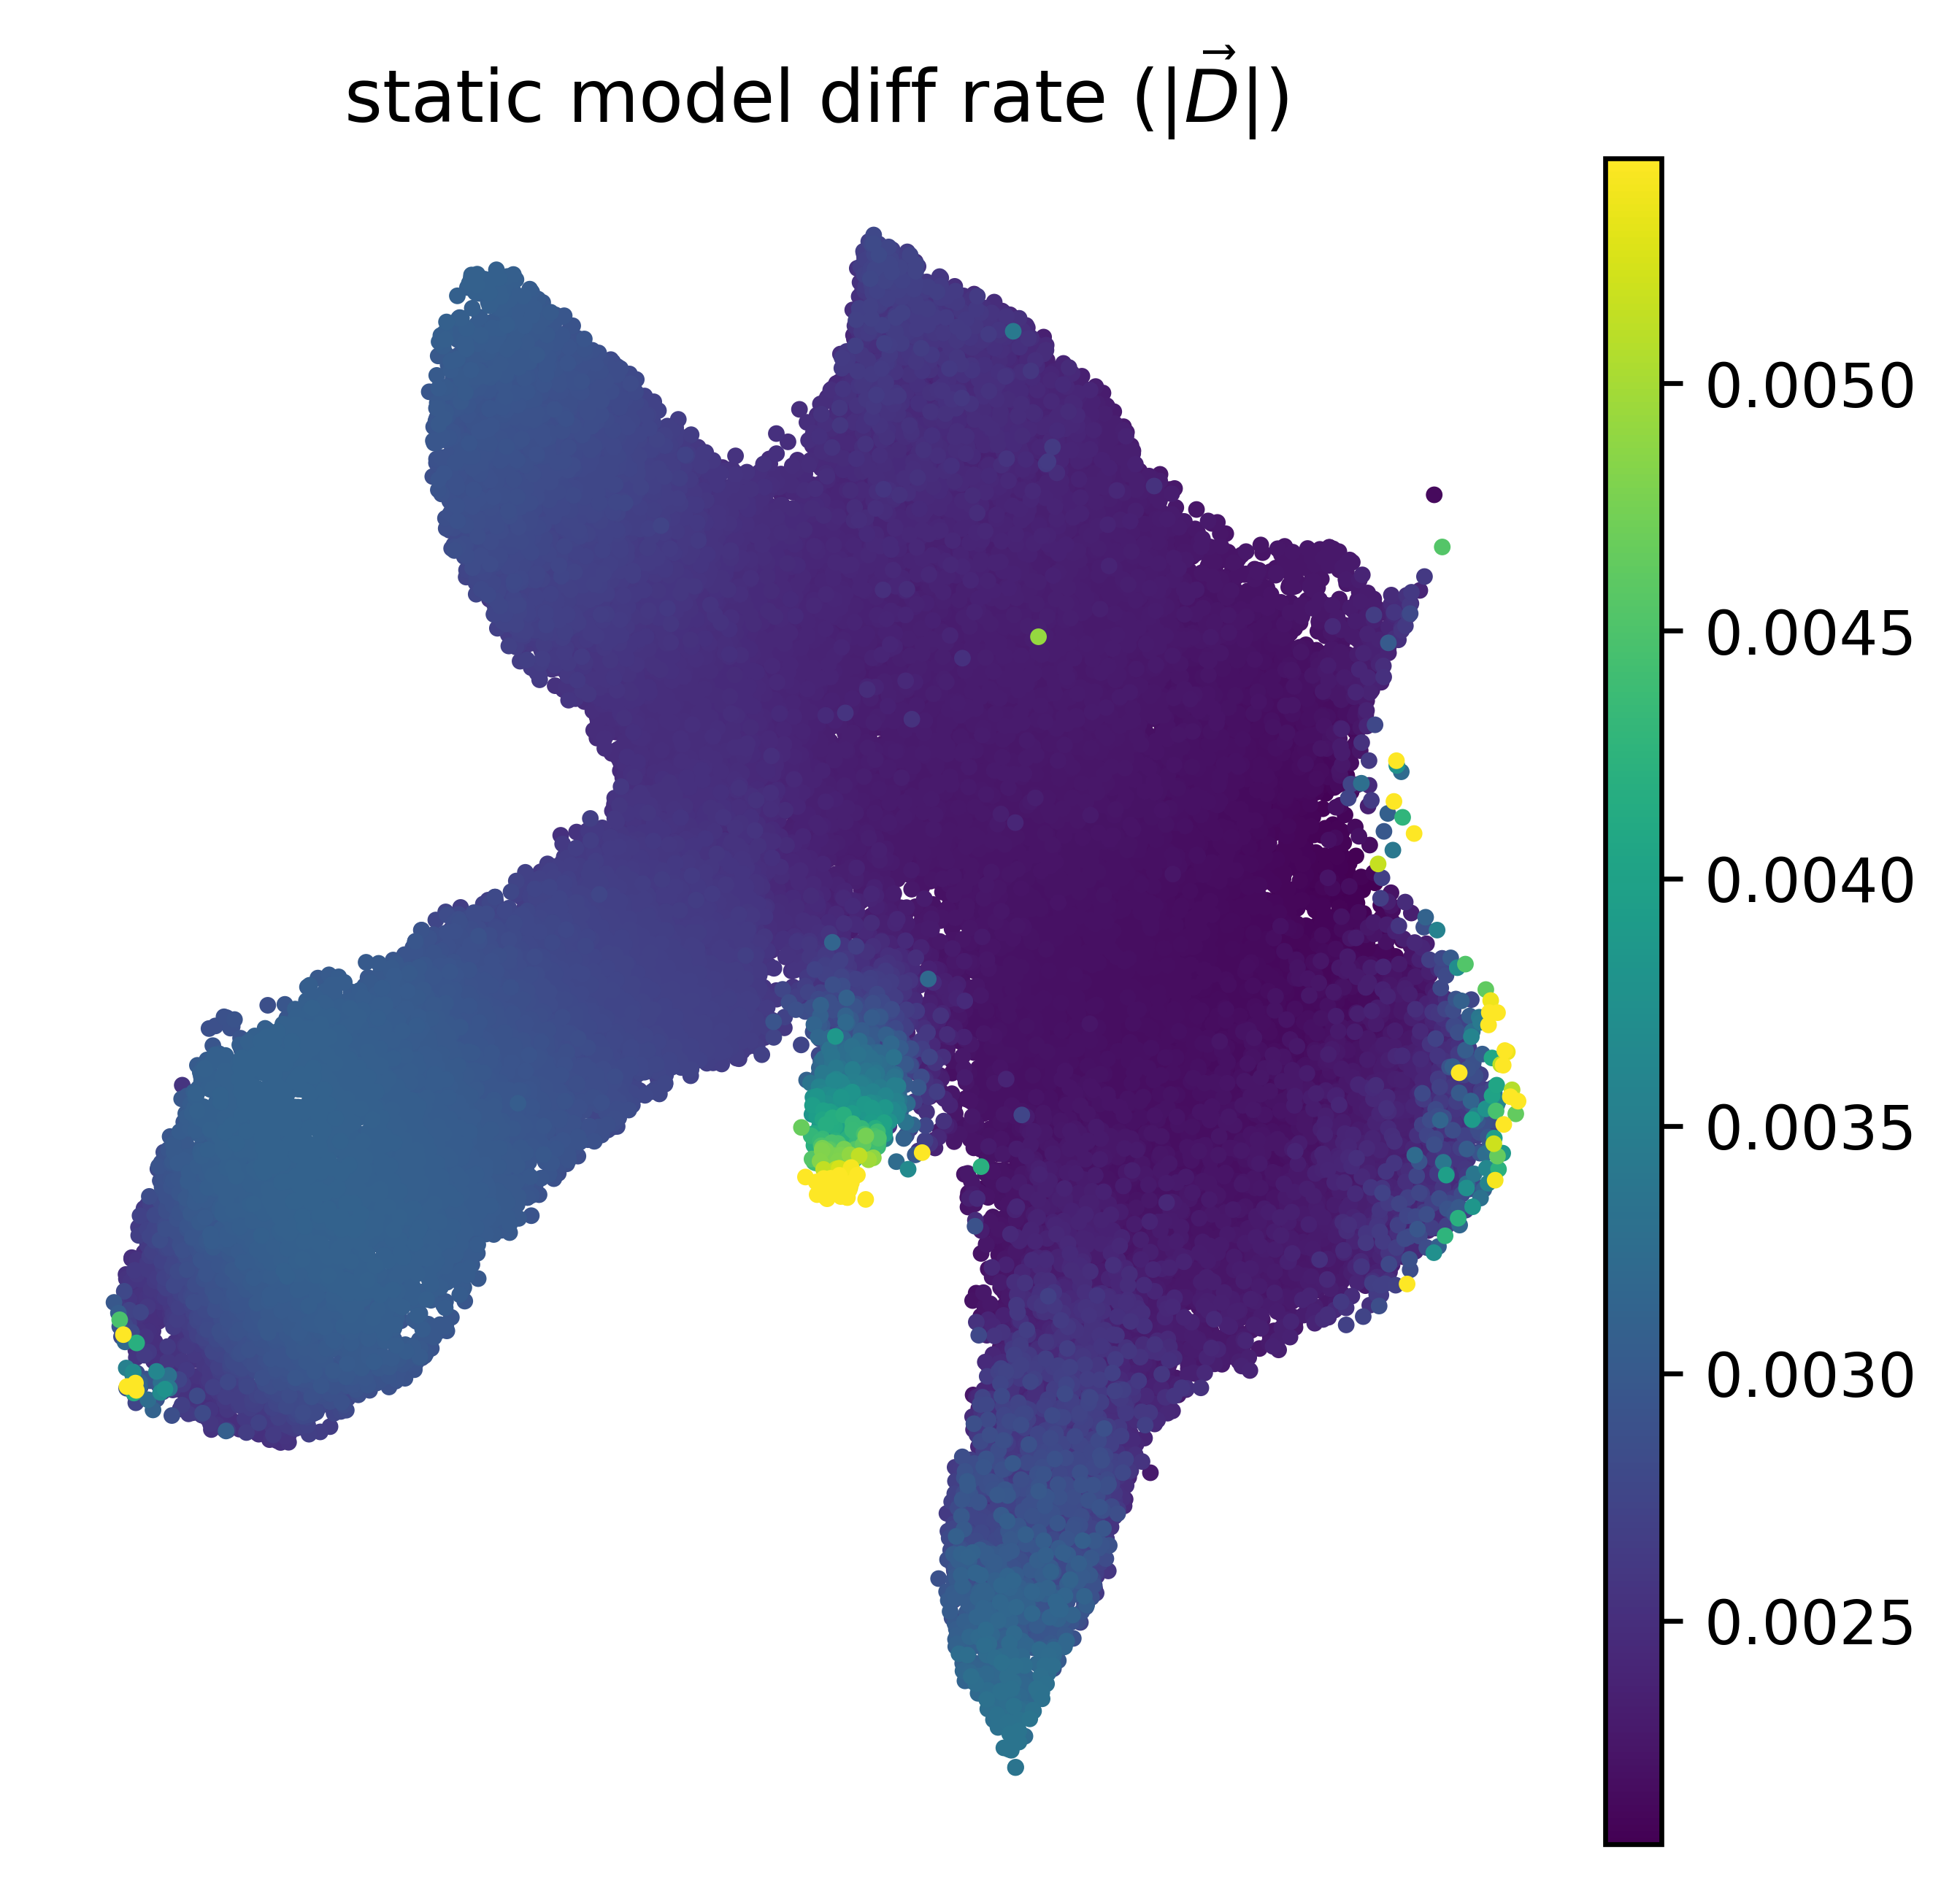

In [121]:
figD